In [6]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

f

In [8]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13382/1534116213.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [12]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X = scaler_x.fit_transform(data)
y = scaler_y.fit_transform(target.reshape(-1,1))

In [20]:
X_train,x_test,Y_train,y_test = train_test_split(X,y,test_size=0.22,random_state=42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1)
]
)
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(X_train,Y_train,epochs=30,validation_split=0.20)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.3324 - mae: 0.8168 - val_loss: 0.7968 - val_mae: 0.5935
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8358 - mae: 0.6270 - val_loss: 0.6088 - val_mae: 0.5267
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6224 - mae: 0.5490 - val_loss: 0.5125 - val_mae: 0.5022
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5022 - mae: 0.4994 - val_loss: 0.4075 - val_mae: 0.4514
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3978 - mae: 0.4486 - val_loss: 0.3231 - val_mae: 0.3887
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3145 - mae: 0.3954 - val_loss: 0.2659 - val_mae: 0.3382
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2589 - mae: 0.3523 - val_loss: 0.2338 - val_mae: 0.3105
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2191 - mae: 0.3251 - val_loss: 0.2151 - val_mae: 0.2945
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.194

In [25]:
loss,mae = model.evaluate(x_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1516 - mae: 0.2288


In [26]:
print(loss)
print(mae)

0.15159709751605988
0.2287834733724594


In [33]:
predictions = model.predict(x_test)
predictions = scaler_y.inverse_transform(predictions)
y_test = scaler_y.inverse_transform(predictions)
for i in range(10):
  print("Predicted value: ",predictions[i][0])
  print("Actual value: ",y_test[i][0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Predicted value:  27.807835
Actual value:  278.0315
Predicted value:  35.36726
Actual value:  347.4876
Predicted value:  15.975184
Actual value:  169.31299
Predicted value:  23.493818
Actual value:  238.39429
Predicted value:  16.316996
Actual value:  172.45355
Predicted value:  21.78716
Actual value:  222.71349
Predicted value:  19.367563
Actual value:  200.48221
Predicted value:  13.834718
Actual value:  149.64635
Predicted value:  23.337317
Actual value:  236.95634
Predicted value:  19.524418
Actual value:  201.92339


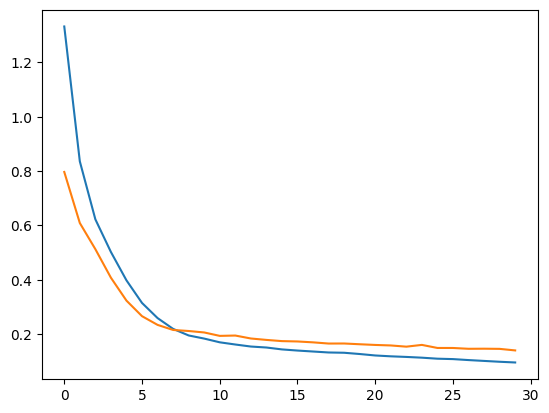

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

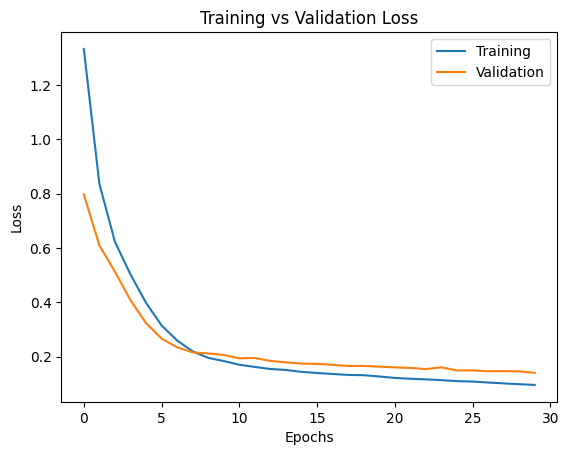

In [38]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend([
    "Training",
    "Validation"
])
plt.show()

In [50]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(data)
y = scaler_y.fit_transform(target.reshape(-1,1))
X_train,x_test,Y_train,y_test = train_test_split(X,y,test_size=0.22,random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss = 'mse',
    metrics = ['mae']
)

history = model.fit(X_train,Y_train,epochs=30,validation_split=0.20)
loss,mae = model.evaluate(x_test,y_test)
print(loss)
print(mae)
predictions = history.predict(x_test)
predictions = scaler_y.inverse_transform(predictions)
y_test = scaler_y.inverse_transform(predictions)
for i in range(10):
  print("Predicted value: ",predictions[i][0])
  print("Actual value: ",y_test[i][0])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training','Validation'])
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13382/370533428.py:10: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.7832 - mae: 0.6642 - val_loss: 0.5728 - val_mae: 0.5194
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4468 - mae: 0.4777 - val_loss: 0.4117 - val_mae: 0.4132
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2923 - mae: 0.3651 - val_loss: 0.2994 - val_mae: 0.3225
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2160 - mae: 0.3140 - val_loss: 0.2590 - val_mae: 0.3141
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1954 - mae: 0.3014 - val_loss: 0.2494 - val_mae: 0.3213
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1801 - mae: 0.2828 - val_loss: 0.2384 - val_mae: 0.3044
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1705 - mae: 0.2692 - val_loss: 0.2249 - val_mae: 0.2888
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1577 - mae: 0.2608 - val_loss: 0.2113 - val_mae: 0.2881
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.145

AttributeError: 'History' object has no attribute 'predict'